<a href="https://colab.research.google.com/github/SANTHOSH-C08/AI-INTERNSHIP/blob/main/water_potability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install snowflake_connector_python pandas scikit-learn

In [ ]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
conn=snowflake.connector.connect(
    user='Santhosh0805',
    password='Santhosh@08052007',
    account='ZSETYPA-YV43213',
    database='water_pb',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)

In [ ]:
query='select * from WATER_PB'
df=pd.read_sql(query,conn)


/tmp/ipykernel_14376/3169495252.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


In [ ]:
df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
df.head()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df.tail()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [ ]:
df.isna()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
3271,False,False,False,False,False,False,False,False,False,False
3272,False,False,False,False,True,False,False,True,False,False
3273,False,False,False,False,True,False,False,False,False,False
3274,False,False,False,False,True,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


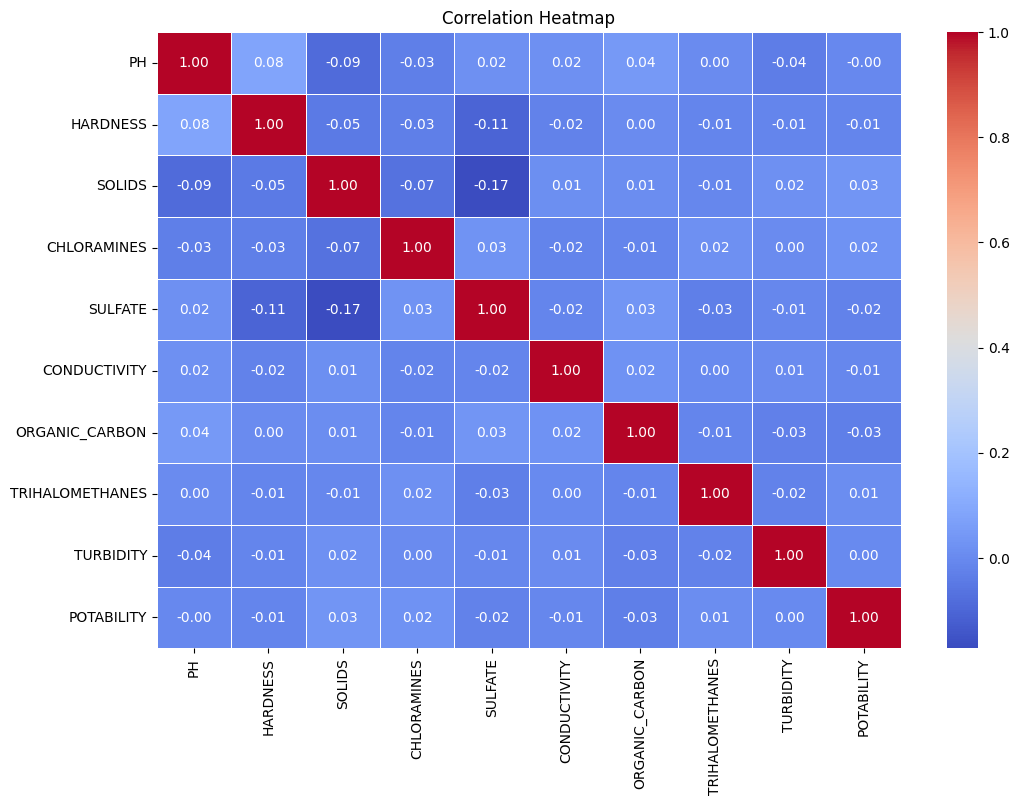

In [ ]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df['PH'] = df['PH'].fillna(df['PH']).mean()
df['SULFATE'] = df['SULFATE'].fillna(df['SULFATE']).mean()
df['TRIHALOMETHANES'] = df['TRIHALOMETHANES'].fillna(df['TRIHALOMETHANES']).mean()

In [ ]:
df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,7.080795,204.890455,20791.318981,7.300212,333.775777,564.308654,10.379783,66.396293,2.963135,0
1,7.080795,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,66.396293,4.500656,0
2,7.080795,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.396293,3.055934,0
3,7.080795,214.373394,22018.417441,8.059332,333.775777,363.266516,18.436524,66.396293,4.628771,0
4,7.080795,181.101509,17978.986339,6.546600,333.775777,398.410813,11.558279,66.396293,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,7.080795,193.681735,47580.991603,7.166639,333.775777,526.424171,13.894419,66.396293,4.435821,1
3272,7.080795,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,7.080795,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,66.396293,3.298875,1
3274,7.080795,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,66.396293,4.708658,1


In [ ]:
df.isna().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


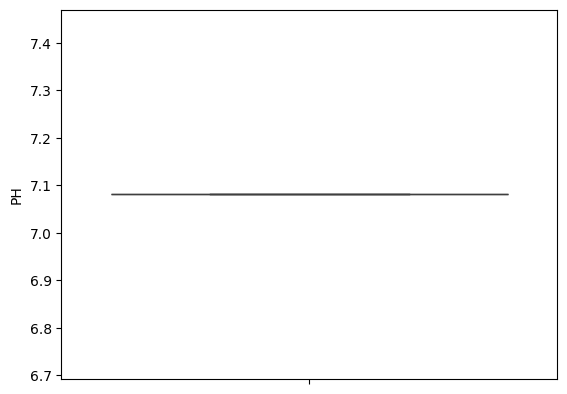

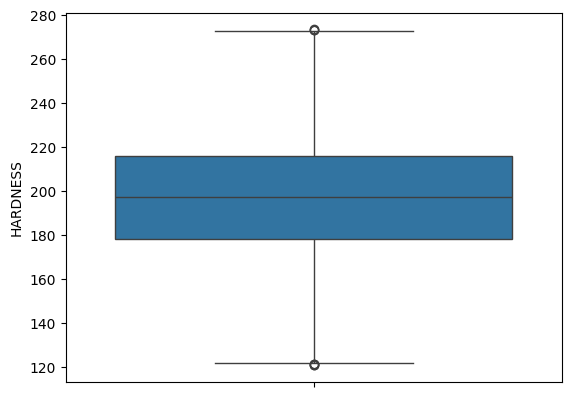

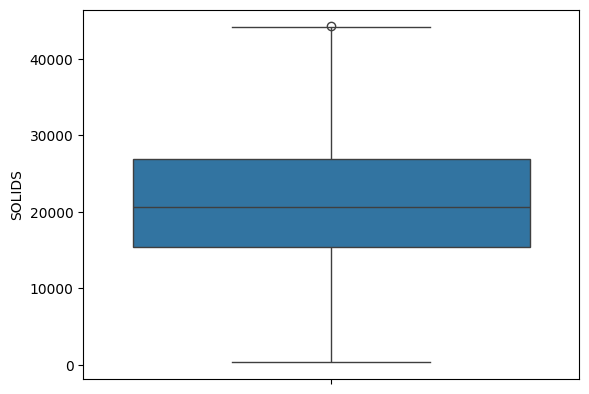

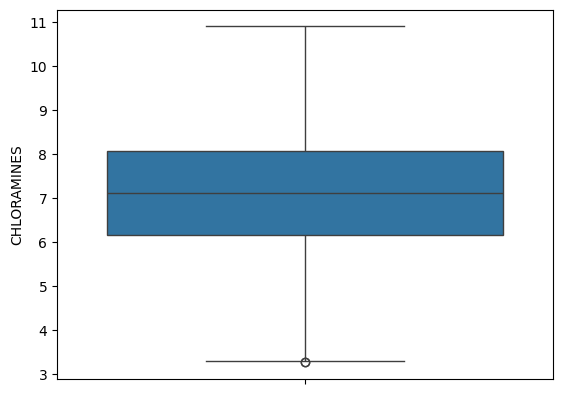

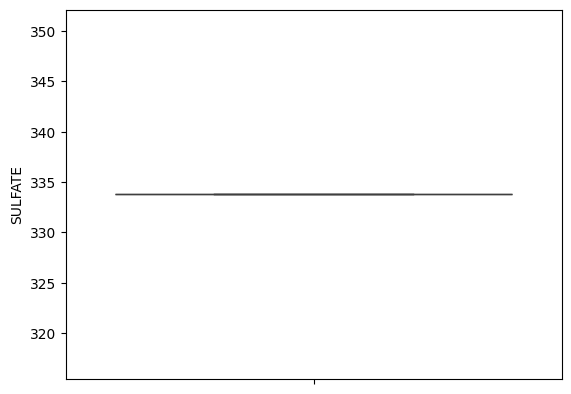

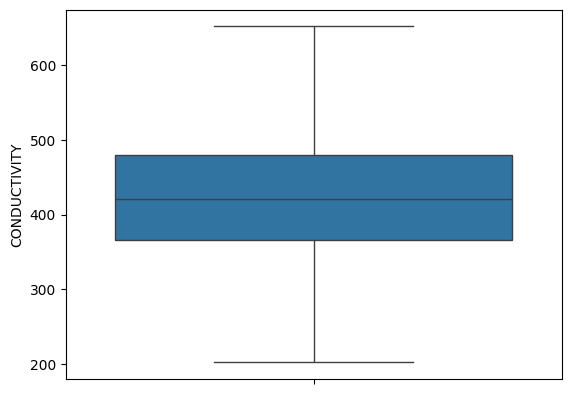

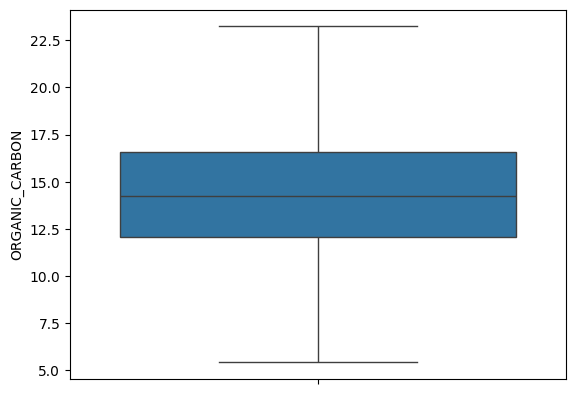

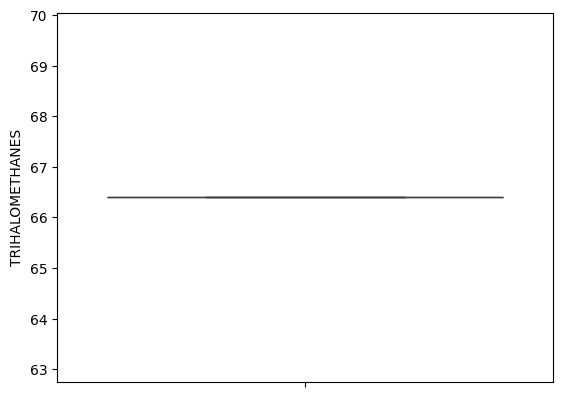

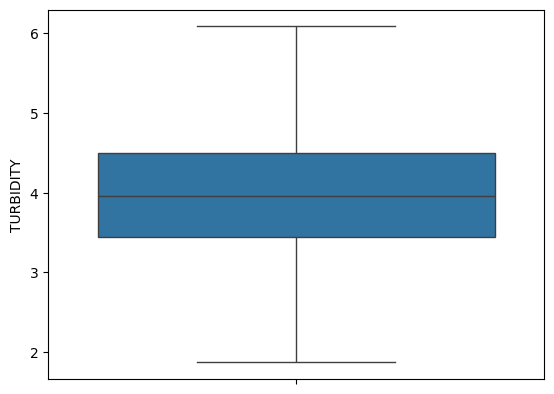

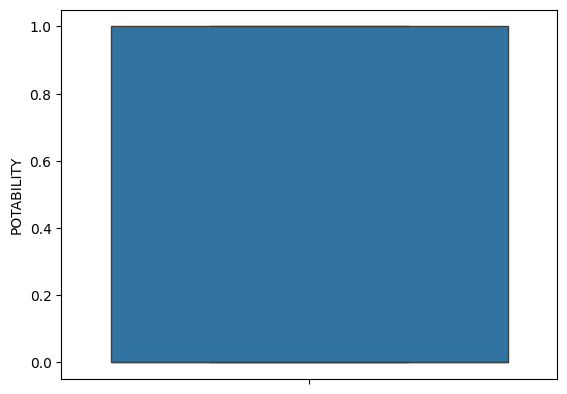

In [ ]:
for i in df.columns:
  if df[i].dtypes !="object":
    sns.boxplot(df[i])
    plt.show()

In [ ]:
col=['HARDNESS','SOLIDS','CHLORAMINES','CONDUCTIVITY','ORGANIC_CARBON','TURBIDITY',]

In [ ]:
for i in col:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  lf=q1-1.5*iqr
  uf=q3+1.5*iqr
  df=df[(lf <= df[i]) & (uf >= df[i])]

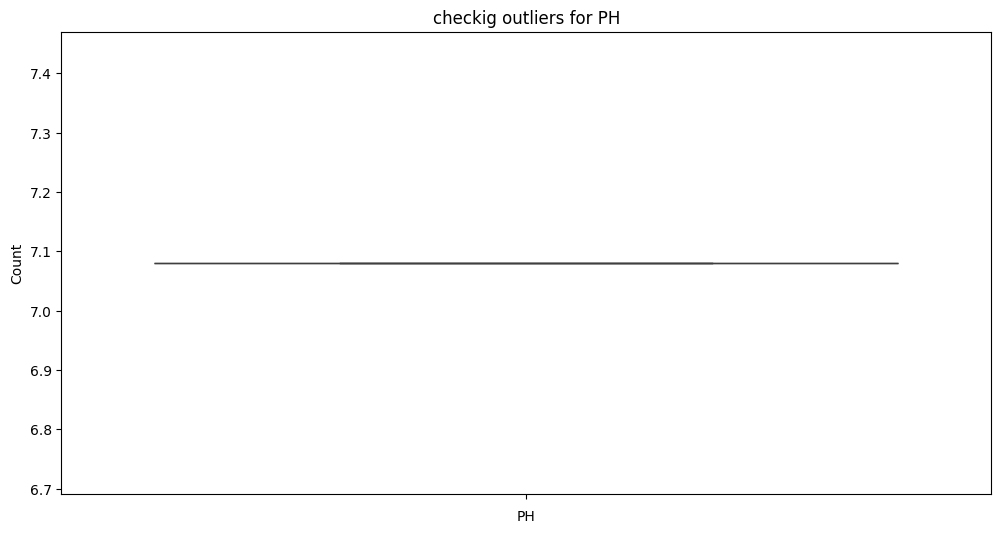

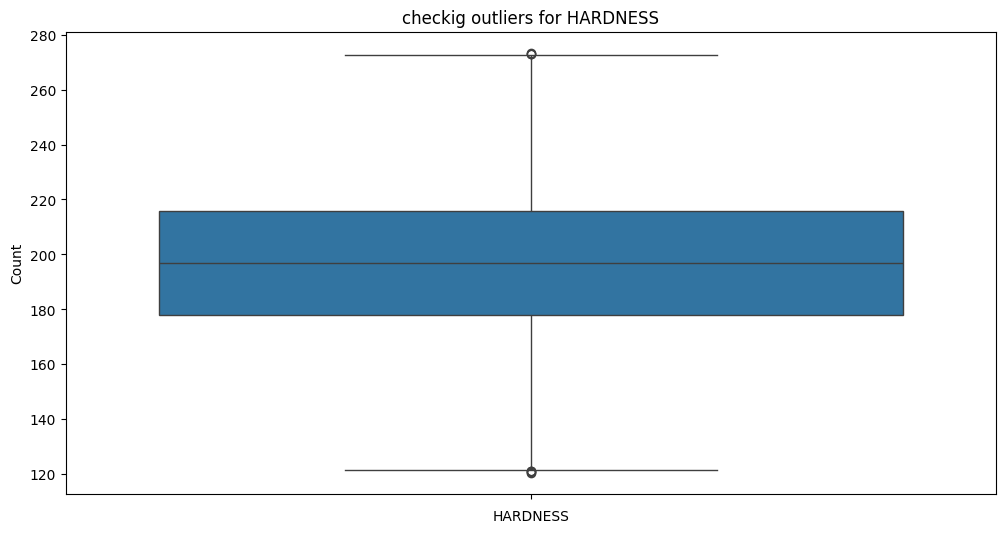

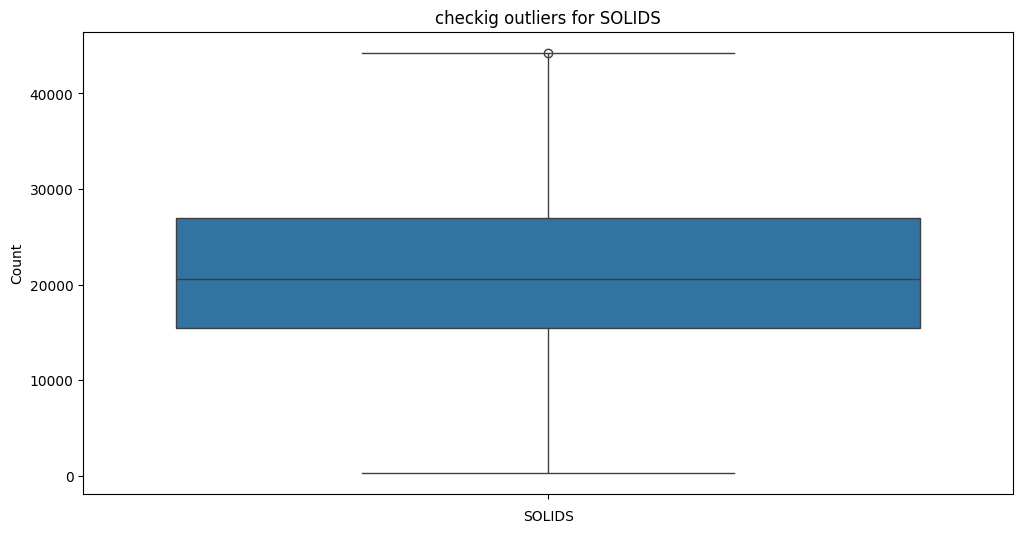

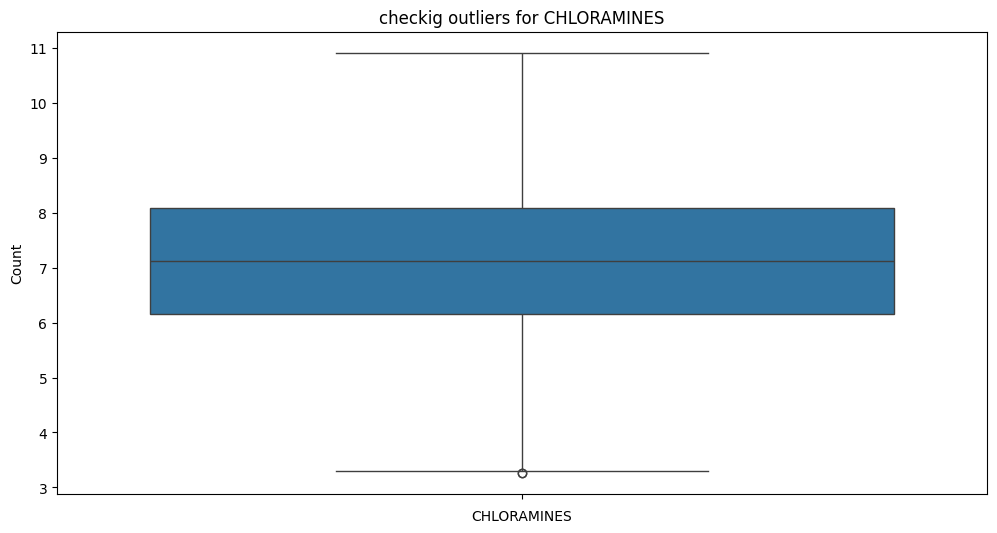

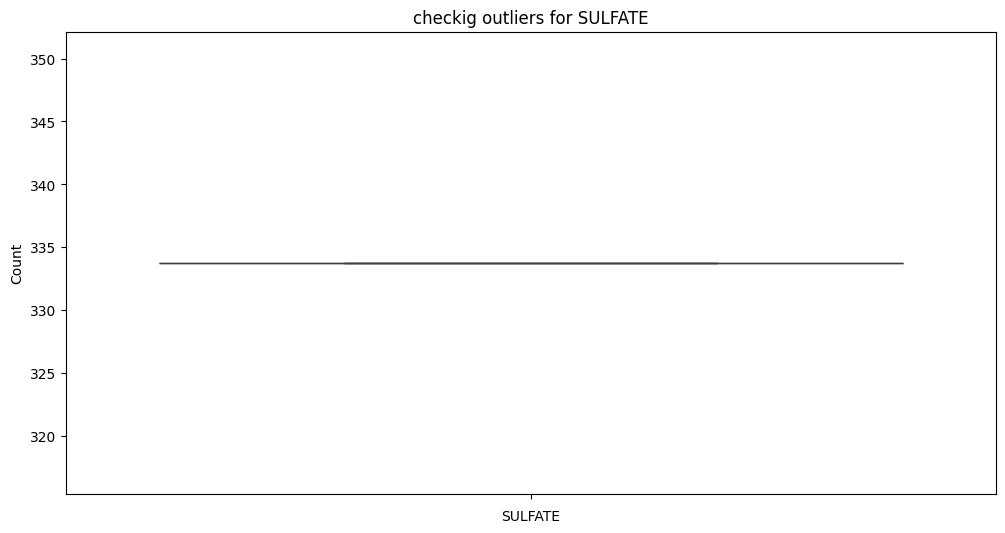

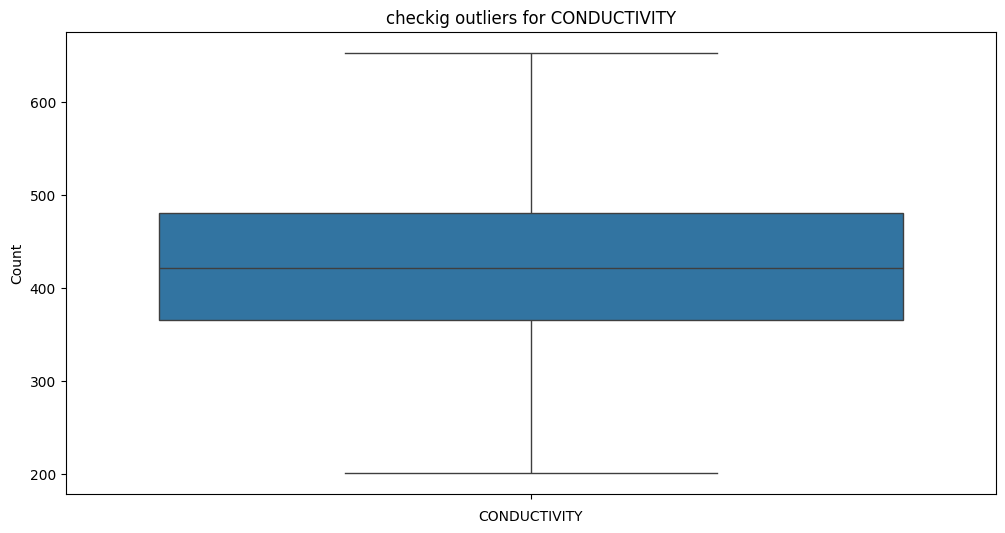

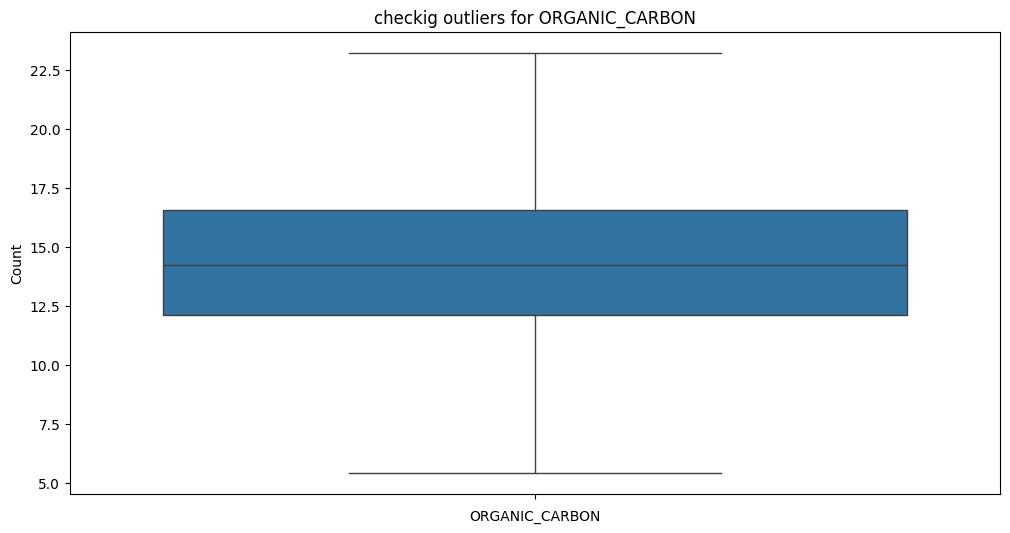

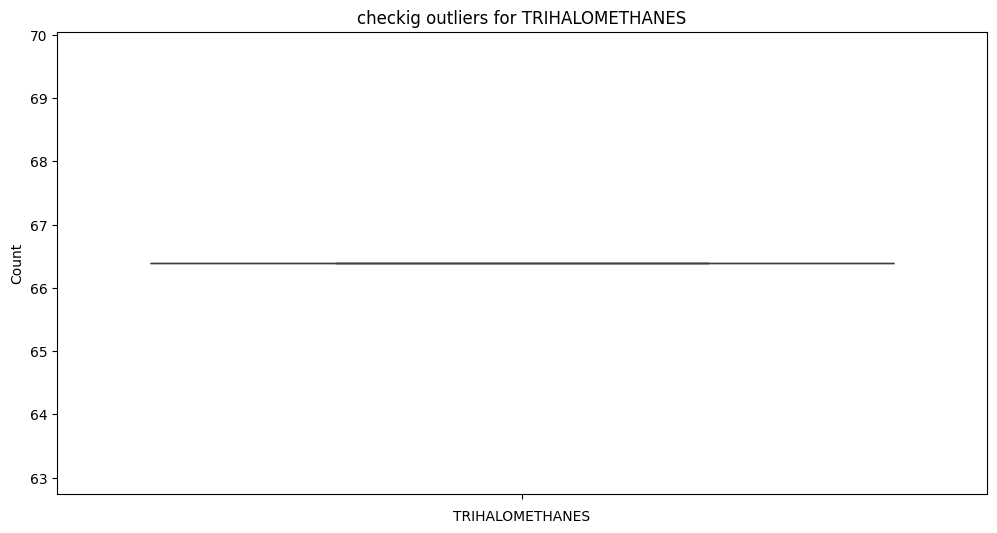

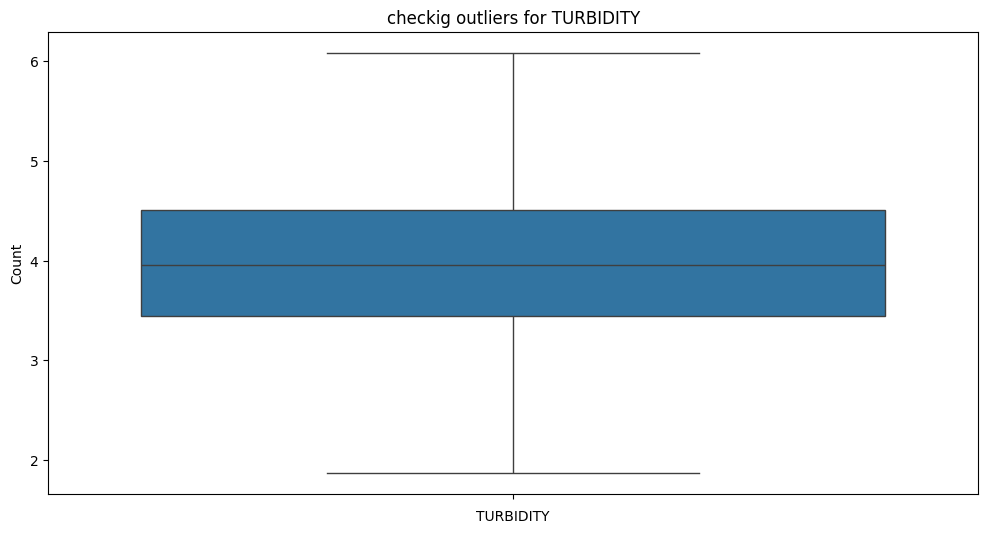

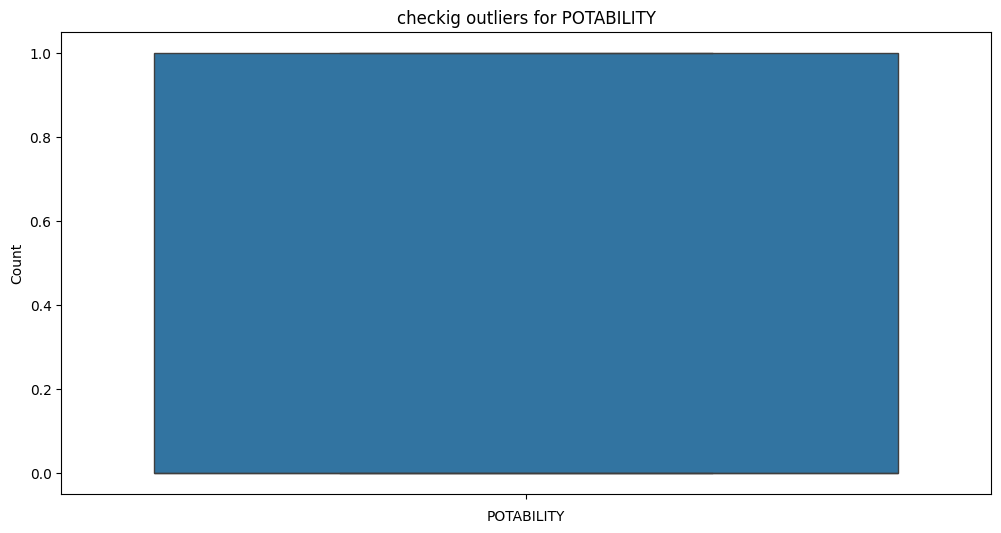

In [ ]:
for i in df.columns:
    plt.figure(figsize = (12,6))
    sns.boxplot(df[i])
    plt.title(f"checkig outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show()

In [ ]:
x = df.iloc[:,:-1]
y = df[["POTABILITY"]]

In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

In [ ]:
x_train

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY
1516,7.080795,157.927492,31598.536377,6.778054,333.775777,464.025483,12.053627,66.396293,3.842578
778,7.080795,182.997199,36412.488260,6.144666,333.775777,414.308055,14.255356,66.396293,3.487816
1194,7.080795,192.647334,14598.951913,6.164621,333.775777,343.895242,17.343806,66.396293,2.820927
3046,7.080795,193.027960,23006.242223,8.098312,333.775777,297.112621,13.475158,66.396293,3.623298
3117,7.080795,227.340186,17605.535759,6.326980,333.775777,489.434591,11.199191,66.396293,4.364426
...,...,...,...,...,...,...,...,...,...
1780,7.080795,191.382410,20506.698418,5.476949,333.775777,445.931207,9.416902,66.396293,5.177964
1201,7.080795,199.930278,19471.465438,7.415406,333.775777,324.937029,16.311696,66.396293,3.470885
1236,7.080795,177.571744,12691.515973,7.170977,333.775777,447.032289,14.376764,66.396293,5.464857
1409,7.080795,208.279181,12806.832327,5.489259,333.775777,472.028286,13.389549,66.396293,3.995857


In [ ]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(x_train, y_train)
y_pred = svm_model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)


Performance of my model: 61.52570480928689


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)

Performance of my model: 61.52570480928689
